Healthcare Dataset
Name: This column represents the name of the patient associated with the healthcare record.

Age: The age of the patient at the time of admission, expressed in years.

Gender: Indicates the gender of the patient, either "Male" or "Female."

Blood Type: The patient's blood type, which can be one of the common blood types (e.g., "A+", "O-", etc.).
Medical Condition: This column specifies the primary medical condition or diagnosis associated with the patient, such as "Diabetes," "Hypertension," "Asthma," and more.
Date of Admission: The date on which the patient was admitted to the healthcare facility.

Doctor: The name of the doctor responsible for the patient's care during their admission.

Hospital: Identifies the healthcare facility or hospital where the patient was admitted.
Insurance Provider: This column indicates the patient's insurance provider, which can be one of several options, including "Aetna," "Blue Cross," "Cigna," "UnitedHealthcare," and "Medicare."

Billing Amount: The amount of money billed for the patient's healthcare services during their admission. This is expressed as a floating-point number.
Room Number: The room number where the patient was accommodated during their admission.
Admission Type: Specifies the type of admission, which can be "Emergency," "Elective," or "Urgent," reflecting the circumstances of the admission.

Discharge Date: The date on which the patient was discharged from the healthcare facility, based on the admission date and a random number of days within a realistic range.

Medication: Identifies a medication prescribed or administered to the patient during their admission. Examples include "Aspirin," "Ibuprofen," "Penicillin," "Paracetamol," and "Lipitor."
Test Results: Describes the results of a medical test conducted during the patient's admission. Possible values include "Normal," "Abnormal," or "Inconclusive," indicating the outcome of the test.

Analytické otázky

1. Demografické: Jaké je rozložení pacientů podle věku a pohlaví? Která věková skupina je nejčastěji hospitalizována?
2. Diagnózy: Která onemocnění jsou nejčastější? Liší se diagnózy podle pohlaví nebo věkové skupiny?
3. Finance: Jaká je průměrná výše účtu podle diagnózy / pojišťovny / typu přijetí? Která pojišťovna "platí nejvíce"?
4. Provoz nemocnice: Jak dlouho pacienti průměrně leží v nemocnici (délka hospitalizace)? Liší se to podle diagnózy nebo typu přijetí?
5. Výsledky testů: Jak se liší výsledky testů podle diagnózy nebo věku?

In [75]:
#1 Import knihoven
import pandas as pd
import seaborn as sns
import importlib
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("../data/healthcare_dataset_cleaned.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 1.  Demografické: Jaké je rozložení pacientů podle věku a pohlaví? Která věková skupina je nejčastěji hospitalizována?

In [6]:
#1.1 Rozdělení pacientů podle věku
df["Age"].describe()

count    55500.000000
mean        51.539459
std         19.602454
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

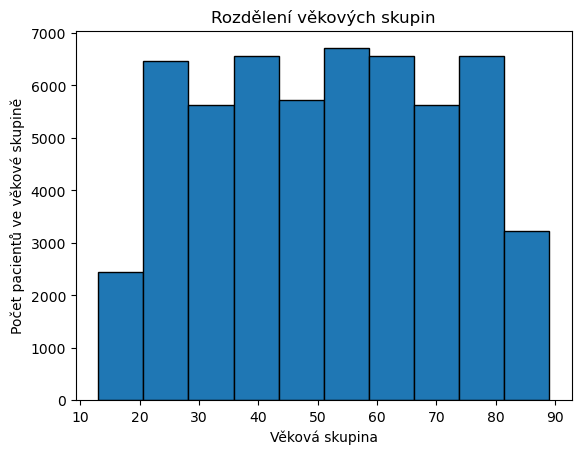

In [7]:
# Histogram 
plt.hist(df["Age"], bins=10, edgecolor="black")
plt.title("Rozdělení věkových skupin")
plt.xlabel("Věková skupina")
plt.ylabel("Počet pacientů ve věkové skupině")
plt.show()

In [8]:
#1.2 Zastoupení pohlaví
df['Gender'].value_counts()

Gender
Male      27774
Female    27726
Name: count, dtype: int64

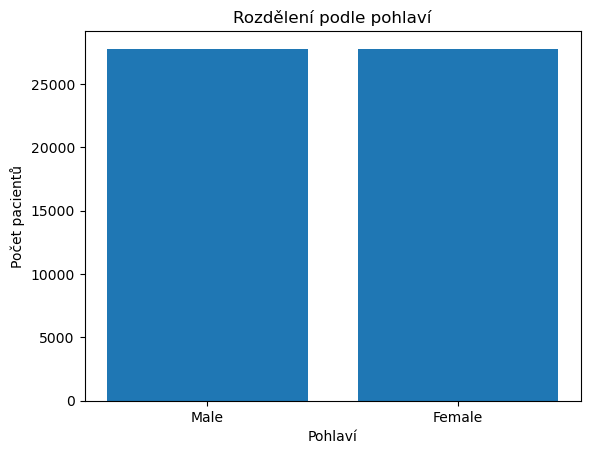

In [9]:
#Rozdělení kategorií podle pohlaví
plt.bar(df['Gender'].value_counts().index, df['Gender'].value_counts())
plt.title("Rozdělení podle pohlaví")
plt.xlabel("Pohlaví")
plt.ylabel("Počet pacientů")
plt.show()


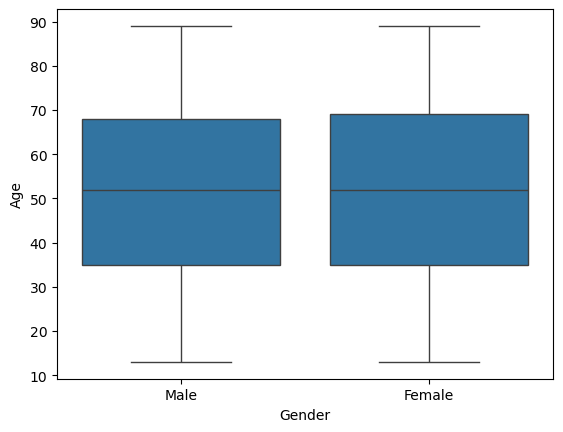

In [10]:
#1.3 Rozdělení podle pohlaví a věku
sns.boxplot(data=df, x= df['Gender'], y=df["Age"])
plt.show()

In [11]:
df.groupby("Gender")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,27726.0,51.578735,19.670281,13.0,35.0,52.0,69.0,89.0
Male,27774.0,51.500252,19.534784,13.0,35.0,52.0,68.0,89.0


**Závěr k otázce č. 1**
Věk pacientů se pohybuje od 13 do 89 let. Průměrný věk je přibližně 51,5 roku a medián 52 let, což ukazuje na poměrně symetrické rozložení. Histogram neukazuje jednu výrazně dominantní věkovou skupinu. Rozložení působí poměrně rovnoměrně, což může naznačovat, že dataset je syntetický nebo uměle vyvážený.

Zastoupení mužů a žen je téměř totožné. V datasetu je 27 774 mužů a 27 726 žen, rozdíl je tedy velmi malý. Na základě těchto počtů nelze pozorovat výraznou nerovnováhu mezi pohlavími.

Rozložení věku podle pohlaví je velmi podobné. Muži i ženy mají stejný medián věku 52 let a podobný rozsah hodnot od 13 do 89 let. Ani boxplot neukazuje výrazný rozdíl mezi pohlavími.

## 2. Diagnózy: Která onemocnění jsou nejčastější? Liší se diagnózy podle pohlaví nebo věkové skupiny?

In [12]:
#2.1 Nejčastější onemocnění
df["Medical Condition"].value_counts() 

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

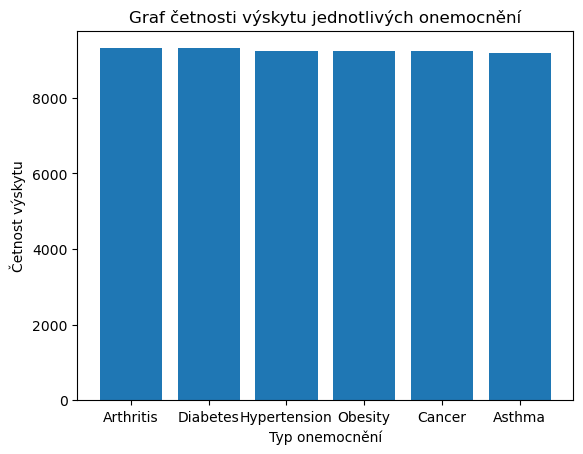

In [13]:
#Grafické zobrazení výskytu onemocnění
plt.bar(df["Medical Condition"].value_counts().index, df["Medical Condition"].value_counts())
plt.title("Graf četnosti výskytu jednotlivých onemocnění")
plt.xlabel("Typ onemocnění")
plt.ylabel("Četnost výskytu")
plt.show()

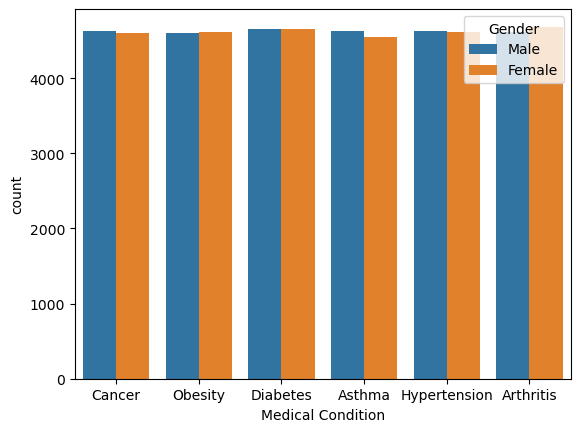

In [14]:
#2.2 Diagnózy podle pohlaví
sns.countplot(x="Medical Condition", hue="Gender", data=df)
plt.show()

In [59]:
#2.3. Diagnózy podle věku
bins = [10, 20, 30, 40, 50, 60, 70, 80, 90]
labels = ["11–20", "21–30", "31–40", "41–50", "51–60", "61–70", "71–80", "81–90"]

df["Age_group"] = pd.cut(df["Age"], bins=bins, labels=labels)


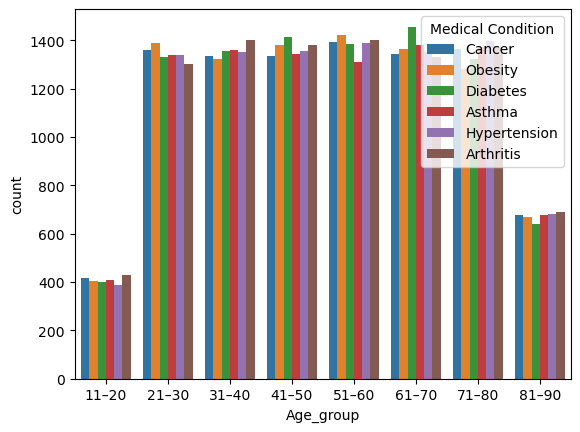

In [60]:
sns.countplot(x="Age_group", hue="Medical Condition", data=df)
plt.show()

**Závěr k otázce číslo 2**

Nejčastější diagnózou je Arthritis, ale rozdíl oproti ostatním diagnózám je velmi malý. Všechny diagnózy se v datasetu vyskytují s podobnou četností, což opět působí jako uměle vyvážené rozložení.

Rozložení diagnóz mezi muži a ženami je velmi podobné. U žádné diagnózy není vidět výrazná převaha jednoho pohlaví. Dataset tedy neukazuje zjevnou souvislost mezi pohlavím a typem diagnózy.

Diagnózy jsou napříč věkovými skupinami rozloženy poměrně rovnoměrně. Ve většině věkových kategorií se počty jednotlivých diagnóz výrazně neliší. Výjimkou jsou skupiny 11–20 a 81–90 let, kde je celkový počet pacientů nižší. U skupiny 11–20 let to může být způsobeno tím, že data začínají až od 13 let. Graf tedy neukazuje výraznou závislost mezi věkem pacienta a typem diagnózy. Vyrovnanost hodnot může naznačovat syntetický nebo uměle vyvážený charakter datasetu.

## 3.Finance: Jaká je průměrná výše účtu podle diagnózy / pojišťovny / typu přijetí? Která pojišťovna "platí nejvíce"?

In [17]:
##3.1 Průměrná výše účtu podle diagnózy

billing_by_conditions = df.groupby("Medical Condition")["Billing Amount"].mean()

In [ ]:
billing_by_conditions.sort_values(ascending=False)

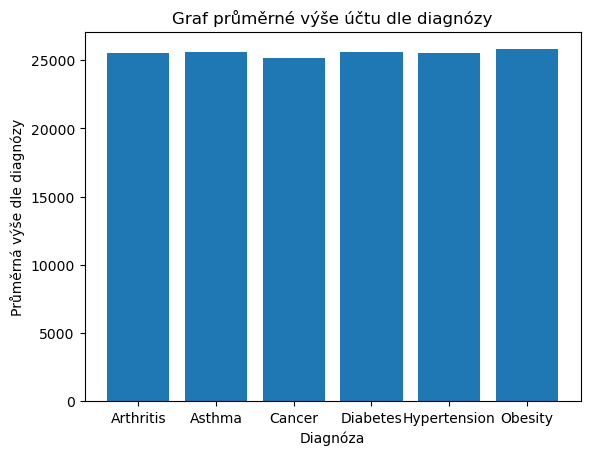

In [18]:
## Zobrazení sloupcového grafu
plt.bar (billing_by_conditions.index, billing_by_conditions.values)
plt.title("Graf průměrné výše účtu dle diagnózy")
plt.ylabel("Průměrná výše dle diagnózy")
plt.xlabel("Diagnóza")
plt.show()

In [19]:
##3.2 Průměrná výše účtu podle pojišťovny

billing_by_insurance = df.groupby("Insurance Provider")["Billing Amount"].mean()

In [63]:
billing_by_insurance.sort_values(ascending=False)

Insurance Provider
Medicare            25615.990508
Blue Cross          25613.011503
Aetna               25553.294506
Cigna               25525.766314
UnitedHealthcare    25389.172390
Name: Billing Amount, dtype: float64

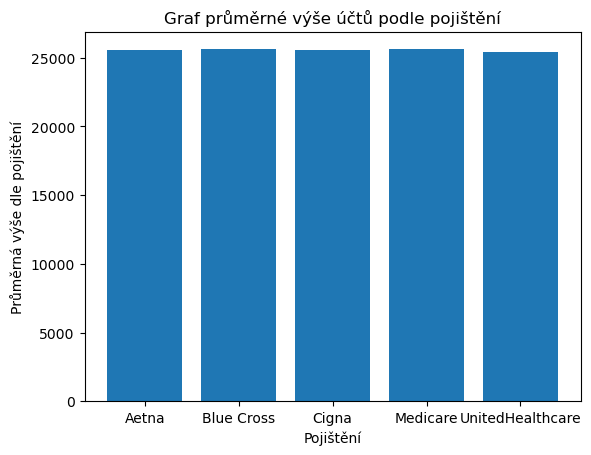

In [73]:
## Grafické znázornění
plt.bar (billing_by_insurance.index, billing_by_insurance.values)
plt.title("Graf průměrné výše účtů podle pojištění")
plt.ylabel("Průměrná výše dle pojištění")
plt.xlabel("Pojištění")
plt.show()

In [22]:
##3.3 Průměrná výše účtu podle pojišťovny

billing_by_admission_type = df.groupby("Admission Type")["Billing Amount"].mean()

In [64]:
billing_by_admission_type.sort_values(ascending=False)

Admission Type
Elective     25602.226311
Urgent       25517.364497
Emergency    25497.397157
Name: Billing Amount, dtype: float64

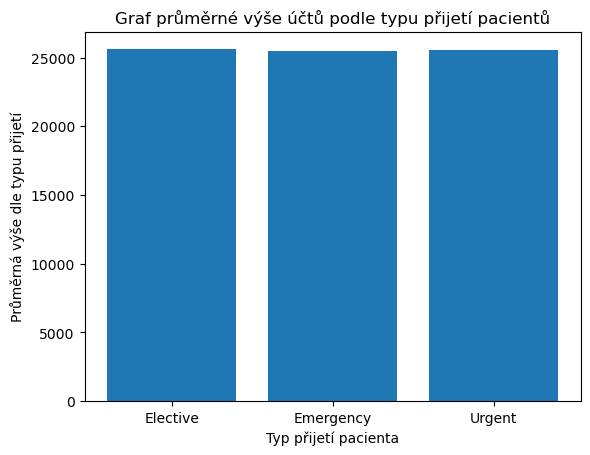

In [23]:
## Grafické znázornění
plt.bar (billing_by_admission_type.index, billing_by_admission_type.values)
plt.title("Graf průměrné výše účtů podle typu přijetí pacientů")
plt.ylabel("Průměrná výše dle typu přijetí")
plt.xlabel("Typ přijetí pacienta")
plt.show()

**Závěr pro otázku 3**

Průměrná výše účtu se mezi jednotlivými diagnózami, pojišťovnami i typy přijetí výrazně neliší. Nejvyšší průměrný účet mají pacienti s diagnózou Obesity, přibližně 25 806. Z pojišťoven má nejvyšší průměrnou hodnotu Medicare, přibližně 25 616. Podle typu přijetí je nejvyšší průměrná hodnota u Elective, přibližně 25 602. Rozdíly mezi kategoriemi jsou však velmi malé, proto nelze říci, že by některá skupina výrazně dominovala. Výsledky opět naznačují poměrně vyvážený charakter datasetu.

## 4. Provoz nemocnice: Jak dlouho pacienti průměrně leží v nemocnici (délka hospitalizace)? Liší se to podle diagnózy nebo typu přijetí?

In [24]:
#4. Předevední textu na datum
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  object        
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  object        
 3   Blood Type          55500 non-null  object        
 4   Medical Condition   55500 non-null  object        
 5   Date of Admission   55500 non-null  datetime64[ns]
 6   Doctor              55500 non-null  object        
 7   Hospital            55500 non-null  object        
 8   Insurance Provider  55500 non-null  object        
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  object        
 12  Discharge Date      55500 non-null  datetime64[ns]
 13  Medication          55500 non-null  object    

In [25]:
# 4.1 Vytvoření proměnné length of hospitalization
df["Length_of_hospitalization"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days


In [22]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Age_group,Length_of_hospitalization
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,21-30,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,61-70,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,71-80,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,21-30,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,41-50,20


In [26]:
#4.2 Průměrná délka hospitalizace
df["Length_of_hospitalization"].mean()

np.float64(15.50900900900901)

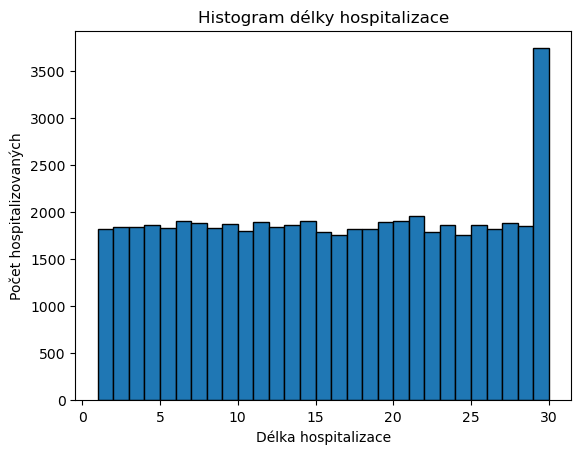

In [74]:
#4.3 Grafické znázornění délky hospitalizace

plt.hist(df["Length_of_hospitalization"], bins="auto", edgecolor="black")
plt.title("Histogram délky hospitalizace")
plt.xlabel("Délka hospitalizace")
plt.ylabel("Počet hospitalizovaných")
plt.show()

In [28]:
#4.4. Kolik pacientů má přesně 30 dní hospitalizace
df[df["Length_of_hospitalization"] == 30].shape

(1874, 17)

In [29]:
#4.5. Maximální doba hospitalizace
df["Length_of_hospitalization"].max()

30

In [30]:
#4.6. Liší se to podle diagnózy?
df.groupby("Medical Condition")["Length_of_hospitalization"].mean()

Medical Condition
Arthritis       15.517404
Asthma          15.696570
Cancer          15.495827
Diabetes        15.422936
Hypertension    15.458626
Obesity         15.464305
Name: Length_of_hospitalization, dtype: float64

In [31]:
# 4.7. 
df.groupby("Admission Type")["Length_of_hospitalization"].mean()

Admission Type
Elective     15.525328
Emergency    15.595052
Urgent       15.408000
Name: Length_of_hospitalization, dtype: float64

## Závěr k otázce č. 4
Průměrná délka hospitalizace je přibližně 15,5 dne. Délka hospitalizace se pohybuje maximálně do 30 dní. V datech je patrné zvýšené množství pacientů s hospitalizací přesně 30 dní, což může souviset s tím, že 30 dní je horní limit v datasetu. Průměrná délka hospitalizace se podle diagnózy ani typu přijetí výrazně neliší.

 ## 5.  Výsledky testů: Jak se liší výsledky testů podle diagnózy nebo věku?

In [35]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Age_group,Length_of_hospitalization
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,21-30,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,61-70,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,71-80,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,21-30,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,41-50,20


In [34]:
df["Test Results"].unique()

array(['Normal', 'Inconclusive', 'Abnormal'], dtype=object)

In [44]:
#5.1. Výsledky testů posle diagnozy
df.groupby("Medical Condition")["Test Results"].value_counts()

Medical Condition  Test Results
Arthritis          Abnormal        3188
                   Inconclusive    3088
                   Normal          3032
Asthma             Normal          3147
                   Inconclusive    3029
                   Abnormal        3009
Cancer             Abnormal        3118
                   Inconclusive    3060
                   Normal          3049
Diabetes           Abnormal        3168
                   Normal          3090
                   Inconclusive    3046
Hypertension       Normal          3142
                   Inconclusive    3091
                   Abnormal        3012
Obesity            Abnormal        3132
                   Normal          3057
                   Inconclusive    3042
Name: count, dtype: int64

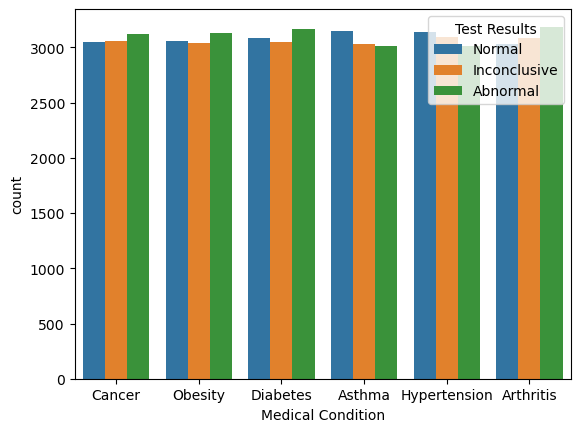

In [ ]:
#5.2. výsledky testů podle diagnózy
sns.countplot(x="Medical Condition", hue="Test Results", data=df)
plt.show()

In [51]:
#5.3. Výsledky testů posle věku
df.groupby("Age_group")["Test Results"].value_counts().sort_values(ascending=False)

C:\Users\danie\AppData\Local\Temp\ipykernel_28364\3847041858.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_group")["Test Results"].value_counts().sort_values(ascending=False)


Age_group  Test Results
41-50      Inconclusive    2779
61-70      Inconclusive    2774
           Abnormal        2757
41-50      Normal          2727
21-30      Normal          2708
61-70      Normal          2697
41-50      Abnormal        2692
21-30      Abnormal        2641
           Inconclusive    2616
51-60      Abnormal        2593
31-40      Normal          2490
           Abnormal        2488
51-60      Inconclusive    2466
71-80      Abnormal        2458
           Normal          2442
51-60      Normal          2440
31-40      Inconclusive    2408
71-80      Inconclusive    2343
81-90      Inconclusive    1661
           Abnormal        1637
           Normal          1601
11-20      Normal          1412
           Abnormal        1361
           Inconclusive    1309
Name: count, dtype: int64

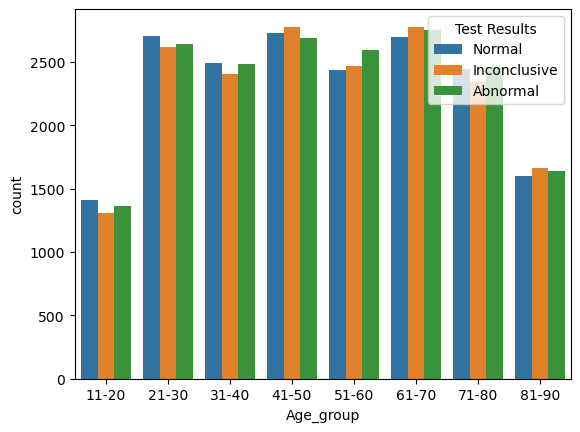

In [47]:
#5.4. výsledky testů podle věku
sns.countplot(x="Age_group", hue="Test Results", data=df)
plt.show()

In [57]:
df.groupby("Age_group").size().sort_values(ascending=False)

C:\Users\danie\AppData\Local\Temp\ipykernel_28364\2556018261.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_group").size().sort_values(ascending=False)


Age_group
61-70    8228
41-50    8198
21-30    7965
51-60    7499
31-40    7386
71-80    7243
81-90    4899
11-20    4082
dtype: int64

Závěr k otázce č. 5

Výsledky testů (Normal, Abnormal, Inconclusive) se výrazně neliší ani podle diagnózy, ani podle věkové skupiny. Hodnoty jsou napříč všemi kategoriemi velmi vyrovnané. 
Nižší počty u věkových skupin 11–20 a 81–90 jsou způsobeny celkově menším počtem pacientů v těchto skupinách, nikoliv odlišným vzorcem výsledků. 
Celková vyváženost výsledků testů může opět naznačovat syntetický nebo uměle vyvážený charakter datasetu.

## Main insights

1. Dataset obsahuje vyrovnané zastoupení pacientů napříč věkovými skupinami.
2. Nejčastější diagnózy se v datasetu vyskytují relativně rovnoměrně.
3. Délka hospitalizace se liší podle diagnózy a typu přijetí.
4. Výše účtu se liší podle diagnózy, pojišťovny a typu přijetí.
5. Výsledky testů lze porovnávat podle diagnózy a věkových skupin.

In [58]:
df.to_csv("../data/healthcare_dataset_cleaned_added_columns.csv", index=False)